Probability (20 to 30 months): 0.06382743803380353
Dataset 1 Mean: 2.415
Dataset 1 Variance: 0.28537142857142855
Dataset 1 Std Dev: 0.534201674062735


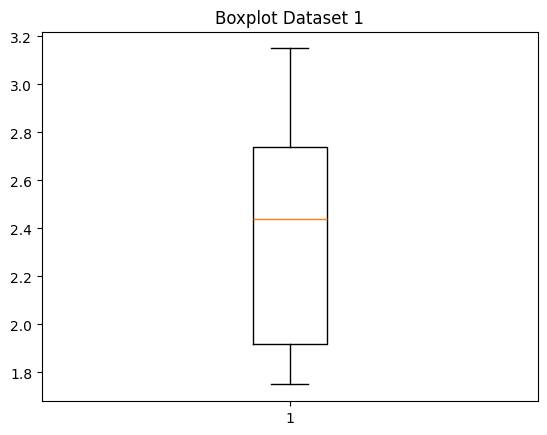

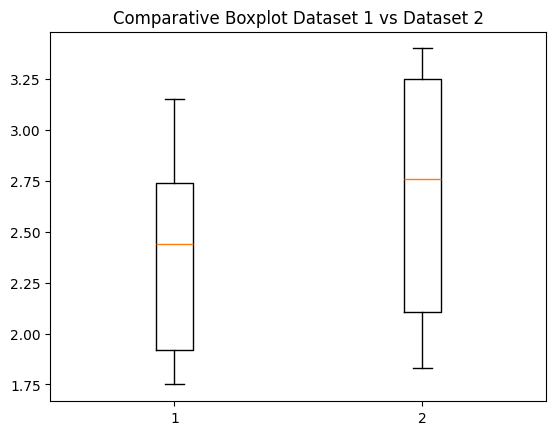

       Name  Weight  Height  Weight_norm Weight_bin        BMI
0    P. Lee      50    1.52     0.094737        Low  21.641274
1  R. Jones     115    1.77     0.778947       High  36.707204
2  J. Smith      96    1.83     0.578947     Medium  28.666129
3  A. Patel      41    1.55     0.000000        Low  17.065557
4   M. Owen      79    1.82     0.400000     Medium  23.849777
5  S. Green     109    1.89     0.715789       High  30.514263
6   N. Cook      73    1.76     0.336842     Medium  23.566632
7  W. Hands     104    1.71     0.663158       High  35.566499
8   P. Rice      64    1.74     0.242105     Medium  21.138856
9  F. Marsh     136    1.78     1.000000       High  42.923873


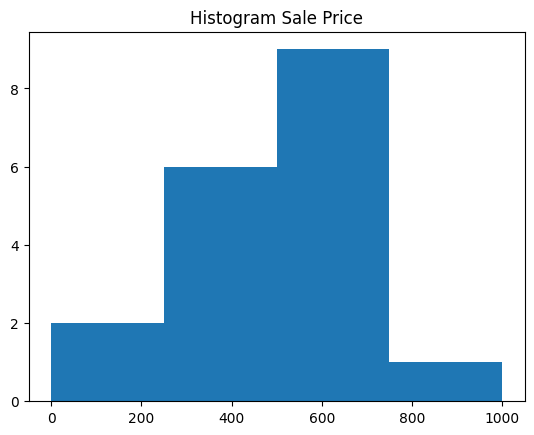


Contingency Table:
Category  Desktop  Laptop  Printer  Scanner
Store                                      
DC              2       2        2        2
NY              3       1        2        4

Customer Summary:
           Count  TotalSale
Customer                   
B. March       3       1700
E. Sims        1        700
G. Hinton      4       2150
H. Fu          1        450
H. Taylor      1        400
J. Bain        1        500
L. Nye         2        900
P. Judd        2        900
S. Cann        1        600
T. Goss        2        750

Store Summary:
       Count  MeanSale
Store                 
DC         8     525.0
NY        10     485.0

Category Summary:
          Count  TotalProfit
Category                    
Desktop       5          295
Laptop        3          470
Printer       4          360
Scanner       6          640


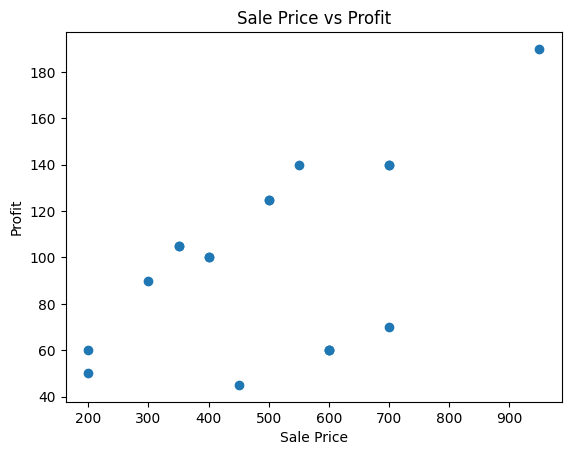

Classes
A    151
B    123
C     68
Name: count, dtype: int64
        Feature 1   Feature 2   Feature 3    Feature 4
count  342.000000  342.000000  342.000000   342.000000
mean    43.921930   17.151170  200.915205  4201.754386
std      5.459584    1.974793   14.061714   801.954536
min     32.100000   13.100000  172.000000  2700.000000
25%     39.225000   15.600000  190.000000  3550.000000
50%     44.450000   17.300000  197.000000  4050.000000
75%     48.500000   18.700000  213.000000  4750.000000
max     59.600000   21.500000  231.000000  6300.000000


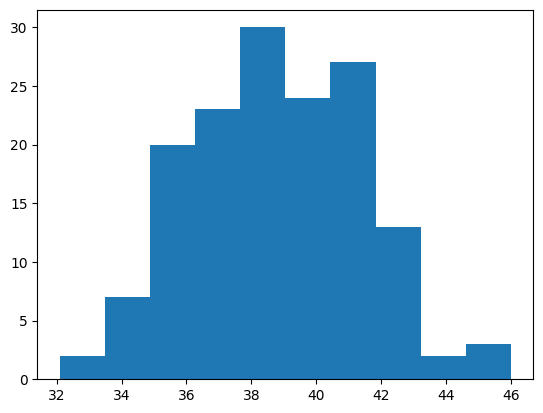

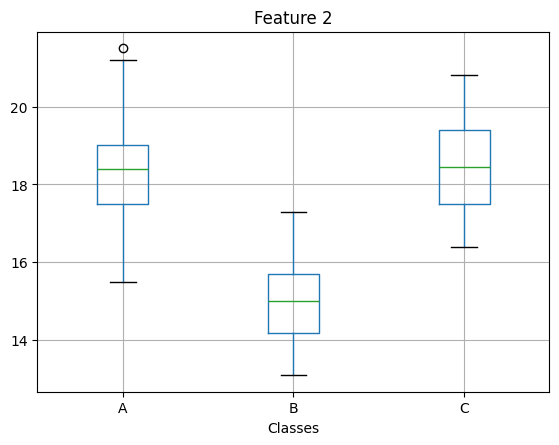

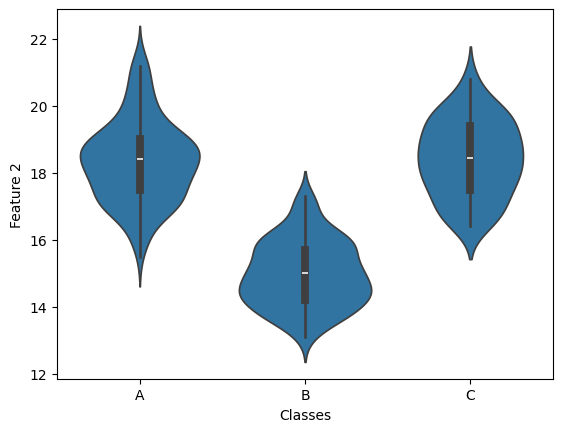

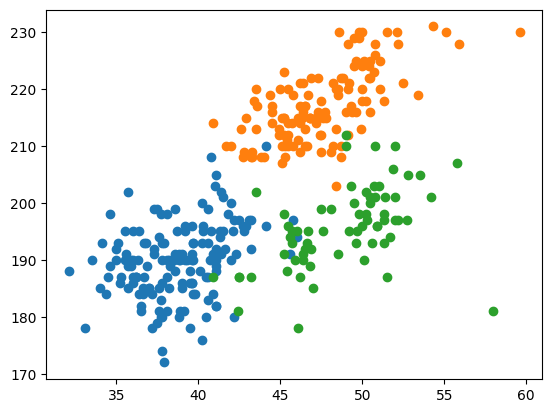

ValueError: not enough values to unpack (expected at least 1, got 0)

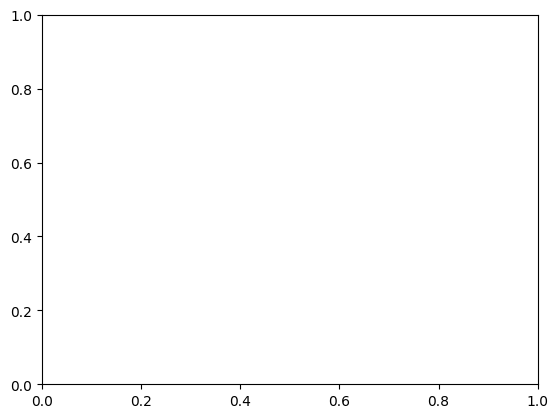

In [18]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Q5 Probability (Normal Distribution)

mean = 42
sd = 8
x1 = 20
x2 = 30

def normal_cdf(x, mu, sigma):
    return 0.5 * (1 + math.erf((x - mu) / (sigma * math.sqrt(2))))

prob = normal_cdf(x2, mean, sd) - normal_cdf(x1, mean, sd)
print("Probability (20 to 30 months):", prob)



# Q7 Statistics + Boxplots


data1 = np.array([1.75, 1.92, 2.62, 2.35, 3.09, 3.15, 2.53, 1.91])
data2 = np.array([1.83, 1.99, 3.13, 3.29, 2.65, 2.87, 3.40, 2.46, 1.89, 3.35])

print("Dataset 1 Mean:", np.mean(data1))
print("Dataset 1 Variance:", np.var(data1, ddof=1))
print("Dataset 1 Std Dev:", np.std(data1, ddof=1))

# Boxplot Dataset 1
plt.figure()
plt.boxplot(data1)
plt.title("Boxplot Dataset 1")
plt.show()

# Comparative Boxplot
plt.figure()
plt.boxplot([data1, data2])
plt.title("Comparative Boxplot Dataset 1 vs Dataset 2")
plt.show()



# Q8 Patient Data Processing



patients = pd.DataFrame({
    "Name": ["P. Lee","R. Jones","J. Smith","A. Patel","M. Owen",
             "S. Green","N. Cook","W. Hands","P. Rice","F. Marsh"],
    "Weight": [50,115,96,41,79,109,73,104,64,136],
    "Height": [1.52,1.77,1.83,1.55,1.82,1.89,1.76,1.71,1.74,1.78]
})

# Min-Max Normalization
patients["Weight_norm"] = (patients["Weight"] - patients["Weight"].min()) / \
                          (patients["Weight"].max() - patients["Weight"].min())

# Binning
def weight_bin(w):
    if w < 60:
        return "Low"
    elif w <= 100:
        return "Medium"
    else:
        return "High"

patients["Weight_bin"] = patients["Weight"].apply(weight_bin)

# BMI
patients["BMI"] = patients["Weight"] / (patients["Height"]**2)

print(patients)



# Q9 Retail Data Analysis


retail = pd.DataFrame({
    "Customer": ["B. March","B. March","B. March","J. Bain","T. Goss","T. Goss",
                 "L. Nye","L. Nye","S. Cann","E. Sims","P. Judd","P. Judd",
                 "G. Hinton","G. Hinton","G. Hinton","G. Hinton","H. Fu","H. Taylor"],
    "Store": ["NY","NY","NY","NY","DC","DC","NY","NY","DC","DC","NY","NY",
              "DC","DC","DC","DC","NY","NY"],
    "Category": ["Laptop","Printer","Scanner","Scanner","Printer","Scanner",
                 "Desktop","Printer","Desktop","Laptop","Desktop","Scanner",
                 "Laptop","Desktop","Printer","Scanner","Desktop","Scanner"],
    "SalePrice": [950,350,400,500,200,550,600,300,600,700,700,200,700,600,350,500,450,400],
    "Profit": [190,105,100,125,60,140,60,90,60,140,70,50,140,60,105,125,45,100]
})

# Histogram
plt.figure()
plt.hist(retail["SalePrice"], bins=[0,250,500,750,1000])
plt.title("Histogram Sale Price")
plt.show()

# Contingency Table
print("\nContingency Table:")
print(pd.crosstab(retail["Store"], retail["Category"]))

# Summary Tables
print("\nCustomer Summary:")
print(retail.groupby("Customer").agg(Count=("SalePrice","count"),
                                     TotalSale=("SalePrice","sum")))

print("\nStore Summary:")
print(retail.groupby("Store").agg(Count=("SalePrice","count"),
                                  MeanSale=("SalePrice","mean")))

print("\nCategory Summary:")
print(retail.groupby("Category").agg(Count=("Profit","count"),
                                     TotalProfit=("Profit","sum")))

# Scatter Plot
plt.figure()
plt.scatter(retail["SalePrice"], retail["Profit"])
plt.xlabel("Sale Price")
plt.ylabel("Profit")
plt.title("Sale Price vs Profit")
plt.show()

#10th question

dat = pd.read_csv("A1.csv")
#10a
frequency = dat["Classes"].value_counts()
print(frequency)
#10b
dat1 = dat.drop("Sample Number",axis=1)
desc = dat1.describe()
print(desc)
#10c
datc = dat[dat["Classes"] == "A"]["Feature 1"]
his1forA = plt.hist(datc)
plt.show()
#10d
dat.boxplot(column = "Feature 2",by = "Classes")
plt.suptitle("")
plt.show()
#10e
import seaborn as sns
sns.violinplot(x="Classes",y="Feature 2",data= dat)
plt.show()
#10f
datf = dat["Classes"].unique()
for c in datf:
    subset = dat[dat["Classes"] == c]
    plt.scatter(
        subset["Feature 1"],
         subset["Feature 3"],
        label=c
    )
plt.show()
#10g
for c in datf:
    subset = dat[dat["Classes"] == c]
    plt.tricontourf(
        subset["Feature 1"],
        subset["Feature 4"],
        label = c
    )
plt.show()

